## Предсказания TLM для AgeVosCeleb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime

In [2]:
PREDICTIONS_PATH = "/home/ext-ivanova-mk@ad.speechpro.com/test_dir/tlm/feature_extraction/agevox_titanet_embeddings/agevox_titanet_metadata_with_predictions.csv"
AGE_METADATA_PATH = "/home/ext-ivanova-mk@ad.speechpro.com/test_dir/vox-profile-release/agevoxceleb/utt2age.test"

In [3]:
df_preds = pd.read_csv(PREDICTIONS_PATH)
print(f"{len(df_preds)} записей")
df_preds.head()

16050 записей


,utterance_id,speaker_id,video_id,segment,age,wav_path,embedding_path,embedding_dim,age_pred
0,id00042/34f5sBShxSo/00001,id00042,34f5sBShxSo,1,70,/mnt/storage/work_dir/databases/voxceleb2/id00...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,34.0
1,id00042/34f5sBShxSo/00002,id00042,34f5sBShxSo,2,70,/mnt/storage/work_dir/databases/voxceleb2/id00...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,32.0
2,id00042/34f5sBShxSo/00003,id00042,34f5sBShxSo,3,70,/mnt/storage/work_dir/databases/voxceleb2/id00...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,33.0
3,id00042/34f5sBShxSo/00004,id00042,34f5sBShxSo,4,70,/mnt/storage/work_dir/databases/voxceleb2/id00...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,32.0
4,id00042/34f5sBShxSo/00005,id00042,34f5sBShxSo,5,70,/mnt/storage/work_dir/databases/voxceleb2/id00...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,33.0


In [4]:
df_age = pd.read_csv(AGE_METADATA_PATH, sep='\s+', header=None, names=['utterance_id', 'true_age'])
age_dict = dict(zip(df_age['utterance_id'], df_age['true_age']))

df_preds['true_age'] = df_preds['utterance_id'].map(age_dict)

missing_age = df_preds['true_age'].isna().sum()
if missing_age > 0:
    df_preds = df_preds.dropna(subset=['true_age'])

df_preds.head()

,utterance_id,speaker_id,video_id,segment,age,wav_path,embedding_path,embedding_dim,age_pred,true_age
0,id00042/34f5sBShxSo/00001,id00042,34f5sBShxSo,1,70,/mnt/storage/work_dir/databases/voxceleb2/id00...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,34.0,70
1,id00042/34f5sBShxSo/00002,id00042,34f5sBShxSo,2,70,/mnt/storage/work_dir/databases/voxceleb2/id00...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,32.0,70
2,id00042/34f5sBShxSo/00003,id00042,34f5sBShxSo,3,70,/mnt/storage/work_dir/databases/voxceleb2/id00...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,33.0,70
3,id00042/34f5sBShxSo/00004,id00042,34f5sBShxSo,4,70,/mnt/storage/work_dir/databases/voxceleb2/id00...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,32.0,70
4,id00042/34f5sBShxSo/00005,id00042,34f5sBShxSo,5,70,/mnt/storage/work_dir/databases/voxceleb2/id00...,/home/ext-ivanova-mk@ad.speechpro.com/test_dir...,192,33.0,70


In [5]:
df_preds['error'] = df_preds['age_pred'] - df_preds['true_age']
df_preds['abs_error'] = abs(df_preds['error'])
df_preds['squared_error'] = df_preds['error'] ** 2

MAE = df_preds['abs_error'].mean()
RMSE = np.sqrt(df_preds['squared_error'].mean())
STD_ERROR = df_preds['error'].std()

# Процент ошибок в пределах
within_1_year = (df_preds['abs_error'] <= 1).mean() * 100
within_3_years = (df_preds['abs_error'] <= 3).mean() * 100
within_5_years = (df_preds['abs_error'] <= 5).mean() * 100
within_10_years = (df_preds['abs_error'] <= 10).mean() * 100

print("\nМетрики оценки TLM модели на Age-VoxCeleb")
print("\nОсновные метрики:")
print(f"MAE  (Mean Absolute Error):     {MAE:.3f} лет")
print(f"RMSE (Root Mean Squared Error): {RMSE:.3f} лет")
print(f"Std of Error (разброс ошибок):  {STD_ERROR:.3f} лет")

print("\nПроцент ошибок в пределах:")
print(f"  ≤ 1 год:   {within_1_year:.1f}%")
print(f"  ≤ 3 года:  {within_3_years:.1f}%")
print(f"  ≤ 5 лет:   {within_5_years:.1f}%")
print(f"  ≤ 10 лет:   {within_10_years:.1f}%")

print("\nСтатистика абсолютных ошибок:")
print(f"  Мин ошибка:  {df_preds['abs_error'].min():.3f} лет")
print(f"  Медиана:     {df_preds['abs_error'].median():.3f} лет")
print(f"  Макс ошибка: {df_preds['abs_error'].max():.3f} лет")


Метрики оценки TLM модели на Age-VoxCeleb

Основные метрики:
MAE  (Mean Absolute Error):     15.483 лет
RMSE (Root Mean Squared Error): 19.409 лет
Std of Error (разброс ошибок):  13.489 лет

Процент ошибок в пределах:
  ≤ 1 год:   6.6%
  ≤ 3 года:  16.2%
  ≤ 5 лет:   25.1%
  ≤ 10 лет:   41.4%

Статистика абсолютных ошибок:
  Мин ошибка:  0.000 лет
  Медиана:     13.563 лет
  Макс ошибка: 56.635 лет


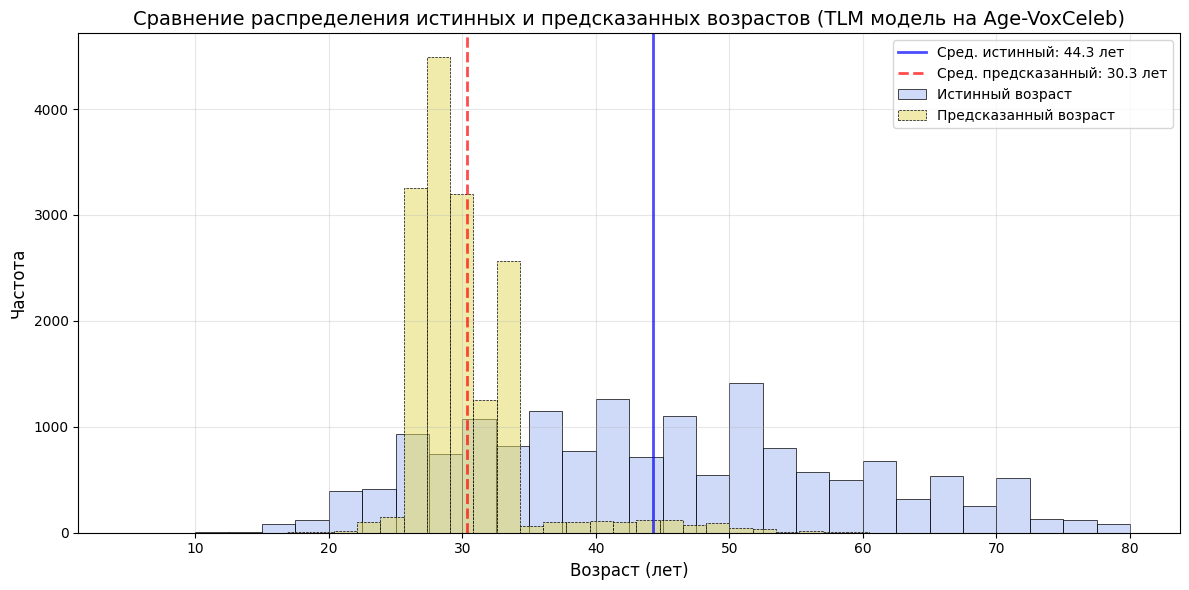

In [6]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df_preds, x='true_age', bins=30, 
             color='#A1B7F4', alpha=0.5, label='Истинный возраст',
             edgecolor='black', linewidth=0.5)
sns.histplot(data=df_preds, x='age_pred', bins=30, 
             color="#E3D958", alpha=0.5, label='Предсказанный возраст',
             edgecolor='black', linewidth=0.5, linestyle='--')

plt.axvline(df_preds['true_age'].mean(), color='blue', linestyle='-', linewidth=2, alpha=0.7,
           label=f'Сред. истинный: {df_preds["true_age"].mean():.1f} лет')
plt.axvline(df_preds['age_pred'].mean(), color='red', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Сред. предсказанный: {df_preds["age_pred"].mean():.1f} лет')

plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Сравнение распределения истинных и предсказанных возрастов (TLM модель на Age-VoxCeleb)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()